# 8.1 感知机与神经网络概述

> **课时**：2课时 | **难度**：⭐⭐⭐ | **竞赛重要度**：⭐⭐⭐⭐⭐

## 📚 学习目标

1. 理解感知机（Perceptron）的基本结构与学习规则
2. 掌握感知机解决线性可分问题的原理
3. 理解感知机的局限性（XOR问题）
4. 掌握多层感知机（MLP）的结构与万能近似定理
5. 能够用 numpy 从零实现感知机

---

## 1. 感知机（Perceptron）的基本结构

感知机是由 Frank Rosenblatt 于 1957 年提出的一种最简单的神经网络模型，它是二分类的线性分类模型。

### 1.1 数学模型

感知机的输出定义为：

$$y = f\left(\sum_{i=1}^{n} w_i x_i + b\right) = f(\mathbf{w}^T \mathbf{x} + b)$$

其中：
- $\mathbf{x} = [x_1, x_2, \ldots, x_n]^T$ 是**输入向量**
- $\mathbf{w} = [w_1, w_2, \ldots, w_n]^T$ 是**权重向量**
- $b$ 是**偏置（bias）**
- $f(\cdot)$ 是**激活函数**（感知机中使用阶跃函数）

### 1.2 激活函数（阶跃函数）

$$f(z) = \begin{cases} 1, & z \geq 0 \\ 0, & z < 0 \end{cases}$$

### 1.3 感知机结构图示

```
        x₁ ──→ [w₁] ──→
        x₂ ──→ [w₂] ──→  Σ(Σwᵢxᵢ + b) ──→ f(·) ──→ y
        x₃ ──→ [w₃] ──→
           ⋮
```

**关键组件**：
| 组件 | 说明 |
|------|------|
| **输入层** | 接收特征向量 $\mathbf{x}$ |
| **权重** | 每个输入对应一个权重 $w_i$，表示该特征的重要性 |
| **偏置** | 控制激活的难易程度 |
| **激活函数** | 阶跃函数，输出 0 或 1 |
| **输出** | 分类结果 |

---

## 2. 感知机学习算法（感知机学习规则）

### 2.1 学习目标

找到一个超平面 $\mathbf{w}^T \mathbf{x} + b = 0$，能够将训练数据正确分类。

### 2.2 损失函数

感知机使用**误分类点数**作为损失，但不可导，因此通常使用：

$$L(\mathbf{w}, b) = -\sum_{x_i \in M} y_i (\mathbf{w}^T \mathbf{x}_i + b)$$

其中 $M$ 为误分类点的集合。

### 2.3 更新规则（随机梯度下降）

对于每个误分类点 $(\mathbf{x}_i, y_i)$：

$$w_j \leftarrow w_j + \eta \cdot y_i \cdot x_{ij}$$
$$b \leftarrow b + \eta \cdot y_i$$

其中 $\eta$ 是**学习率**（通常取 0.01 ~ 1.0）。

### 2.4 算法流程

```
1. 初始化 w = 0, b = 0
2. 对每个训练样本 (xᵢ, yᵢ):
   a. 计算 ŷ = f(w·xᵢ + b)
   b. 如果 ŷ ≠ yᵢ（误分类）:
      - w ← w + η · yᵢ · xᵢ
      - b ← b + η · yᵢ
3. 重复步骤2直到所有样本正确分类
```

> **收敛性**：如果训练数据**线性可分**，感知机算法一定在有限步内收敛（Novikoff定理）。

---

## 3. 感知机的局限性——XOR 问题

### 3.1 什么是 XOR 问题？

XOR（异或）的真值表：

| $x_1$ | $x_2$ | $x_1 \oplus x_2$ |
|:-----:|:-----:|:-----------------:|
|   0   |   0   |         0         |
|   0   |   1   |         1         |
|   1   |   0   |         1         |
|   1   |   1   |         0         |

### 3.2 为什么单层感知机无法解决 XOR？

**核心原因**：XOR 问题**不是线性可分**的。

- AND、OR 是线性可分的（可以用一条直线分开两类）
- XOR 不是线性可分的（无法用一条直线分开两类）

> **Minsky & Papert (1969)** 在《Perceptrons》中证明了这一点，直接导致了第一次 AI 寒冬。

### 3.3 可视化理解

在二维平面上，AND 和 OR 的正负样本可以被一条直线分隔，但 XOR 不能。

---

## 4. 多层感知机（MLP）

### 4.1 解决 XOR 的方法：添加隐藏层

通过添加一个**隐藏层**，MLP 可以解决 XOR 问题：

```
输入层 → 隐藏层 → 输出层
 x₁ ─→            ─→
          h₁ ─→
 x₂ ─→            ─→ → ŷ
          h₂ ─→
```

隐藏层学习新的特征表示，使得在隐藏层的空间中，数据变得线性可分。

### 4.2 MLP 的通用结构

$$\mathbf{h} = f_1(\mathbf{W}_1 \mathbf{x} + \mathbf{b}_1)$$
$$\mathbf{y} = f_2(\mathbf{W}_2 \mathbf{h} + \mathbf{b}_2)$$

| 层级 | 公式 | 说明 |
|------|------|------|
| 输入层 | $\mathbf{x}$ | 原始特征 |
| 隐藏层 | $\mathbf{h} = f_1(\mathbf{W}_1 \mathbf{x} + \mathbf{b}_1)$ | 特征变换 |
| 输出层 | $\mathbf{y} = f_2(\mathbf{W}_2 \mathbf{h} + \mathbf{b}_2)$ | 最终输出 |

### 4.3 万能近似定理（Universal Approximation Theorem）

> **定理（Cybenko 1989, Hornik 1991）**：具有至少一个隐藏层（含有限个神经元）的前馈神经网络，只要激活函数是非多项式的连续函数，就可以以任意精度逼近 $\mathbb{R}^n$ 中紧集上的任意连续函数。

**数学表达**：

$$\forall \epsilon > 0, \exists \mathbf{W}, \mathbf{b}: \quad |F(\mathbf{x}) - f(\mathbf{x})| < \epsilon, \quad \forall \mathbf{x} \in K$$

其中 $K$ 是紧集，$f$ 是连续函数。

> **注意**：万能近似定理说明"存在"这样的网络，但没有说明如何找到它，也没有说明需要多大的网络。

---

## 5. 前馈神经网络的数据流

### 5.1 前向传播

数据从输入层逐层向前传播到输出层：

$$\mathbf{a}^{(0)} = \mathbf{x}$$
$$\mathbf{z}^{(l)} = \mathbf{W}^{(l)} \mathbf{a}^{(l-1)} + \mathbf{b}^{(l)}$$
$$\mathbf{a}^{(l)} = f^{(l)}(\mathbf{z}^{(l)})$$

其中：
- $\mathbf{a}^{(l)}$ 是第 $l$ 层的激活输出
- $\mathbf{z}^{(l)}$ 是第 $l$ 层的加权输入
- $\mathbf{W}^{(l)}$ 是第 $l$ 层的权重矩阵
- $f^{(l)}$ 是第 $l$ 层的激活函数

### 5.2 关键特性

| 特性 | 说明 |
|------|------|
| **无环** | 前馈网络中没有环路 |
| **逐层计算** | 每层只依赖前一层的输出 |
| **参数共享** | 不同样本共享同一组权重 |

---

## 6. 竞赛考点总结

| 考点 | 重要程度 |
|------|---------|
| 感知机数学模型 $y = f(\mathbf{w}^T\mathbf{x} + b)$ | ⭐⭐⭐⭐⭐ |
| 感知机学习规则 $w \leftarrow w + \eta y x$ | ⭐⭐⭐⭐⭐ |
| XOR 问题的不可分性 | ⭐⭐⭐⭐⭐ |
| MLP 的结构（输入层-隐藏层-输出层） | ⭐⭐⭐⭐ |
| 万能近似定理 | ⭐⭐⭐⭐ |
| 前向传播的数据流 | ⭐⭐⭐⭐ |


## 7. 代码实战

### 7.1 从零实现单层感知机

In [8]:
import numpy as np
import matplotlib.pyplot as plt
# 设置 matplotlib 支持中文字体显示，推荐使用 SimHei（黑体）或其他常见中易字体
plt.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体
plt.rcParams['axes.unicode_minus'] = False    # 正常显示负号

# ============================================
# 单层感知机的 numpy 实现
# ============================================

class Perceptron:
    """单层感知机分类器"""
    
    def __init__(self, input_dim, lr=0.1, epochs=100):
        """
        参数:
            input_dim: 输入维度
            lr: 学习率
            epochs: 最大训练轮数
        """
        self.W = np.zeros(input_dim)
        self.b = 0.0
        self.lr = lr
        self.epochs = epochs
        self.history = []  # 记录训练历史
    
    def step_function(self, z):
        """阶跃激活函数"""
        return np.where(z >= 0, 1, 0)
    
    def predict(self, X):
        """预测"""
        z = np.dot(X, self.W) + self.b
        return self.step_function(z)
    
    def train(self, X, y):
        """
        训练感知机
        参数:
            X: 训练数据, shape (n_samples, n_features)
            y: 标签, shape (n_samples,), 值为 0 或 1
        """
        for epoch in range(self.epochs):
            mistakes = 0
            for xi, yi in zip(X, y):
                y_pred = self.predict(xi.reshape(1, -1))[0]
                if y_pred != yi:
                    # 将标签转换为 {-1, +1} 以便使用统一公式
                    y_signed = 2 * yi - 1
                    self.W += self.lr * y_signed * xi
                    self.b += self.lr * y_signed
                    mistakes += 1
            self.history.append(mistakes)
            if mistakes == 0:
                print(f"✓ 在第 {epoch+1} 轮收敛，所有样本正确分类！")
                break
        else:
            print(f"⚠ 训练 {self.epochs} 轮后未完全收敛，仍有 {mistakes} 个误分类点")
        
        return self.history


print("=" * 60)
print("单层感知机已定义完毕")
print("=" * 60)
print(f"  - 输入维度: 由数据自动确定")
print(f"  - 学习率: 默认 0.1")
print(f"  - 最大训练轮数: 默认 100")
print(f"  - 激活函数: 阶跃函数")
print("=" * 60)

单层感知机已定义完毕
  - 输入维度: 由数据自动确定
  - 学习率: 默认 0.1
  - 最大训练轮数: 默认 100
  - 激活函数: 阶跃函数


### 7.2 解决 AND 问题

In [9]:
# ============================================
# AND 问题
# ============================================

# AND 真值表
X_and = np.array([[0, 0],
                   [0, 1],
                   [1, 0],
                   [1, 1]])
y_and = np.array([0, 0, 0, 1])

print("AND 真值表:")
print("x₁  x₂  | y")
print("---------|---")
for xi, yi in zip(X_and, y_and):
    print(f" {xi[0]}   {xi[1]}  | {yi}")

# 训练感知机
print("\n训练感知机解决 AND 问题...")
perceptron_and = Perceptron(input_dim=2, lr=0.1, epochs=20)
history_and = perceptron_and.train(X_and, y_and)

print(f"\n学到的权重: W = {perceptron_and.W}")
print(f"学到的偏置: b = {perceptron_and.b}")

# 验证预测
print("\n预测结果:")
for xi in X_and:
    pred = perceptron_and.predict(xi.reshape(1, -1))[0]
    print(f"  输入 {xi} → 预测 {pred}")

AND 真值表:
x₁  x₂  | y
---------|---
 0   0  | 0
 0   1  | 0
 1   0  | 0
 1   1  | 1

训练感知机解决 AND 问题...
✓ 在第 4 轮收敛，所有样本正确分类！

学到的权重: W = [0.2 0.1]
学到的偏置: b = -0.20000000000000004

预测结果:
  输入 [0 0] → 预测 0
  输入 [0 1] → 预测 0
  输入 [1 0] → 预测 0
  输入 [1 1] → 预测 1


### 7.3 解决 OR 问题

In [10]:
# ============================================
# OR 问题
# ============================================

# OR 真值表
X_or = np.array([[0, 0],
                  [0, 1],
                  [1, 0],
                  [1, 1]])
y_or = np.array([0, 1, 1, 1])

print("OR 真值表:")
print("x₁  x₂  | y")
print("---------|---")
for xi, yi in zip(X_or, y_or):
    print(f" {xi[0]}   {xi[1]}  | {yi}")

# 训练感知机
print("\n训练感知机解决 OR 问题...")
perceptron_or = Perceptron(input_dim=2, lr=0.1, epochs=20)
history_or = perceptron_or.train(X_or, y_or)

print(f"\n学到的权重: W = {perceptron_or.W}")
print(f"学到的偏置: b = {perceptron_or.b}")

OR 真值表:
x₁  x₂  | y
---------|---
 0   0  | 0
 0   1  | 1
 1   0  | 1
 1   1  | 1

训练感知机解决 OR 问题...
✓ 在第 4 轮收敛，所有样本正确分类！

学到的权重: W = [0.1 0.1]
学到的偏置: b = -0.1


### 7.4 可视化决策边界（AND 和 OR）

C:\Users\Terry\AppData\Local\Temp\ipykernel_19848\1247964835.py:13: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(X[i, 0], X[i, 1], c=color, marker=marker, s=200,


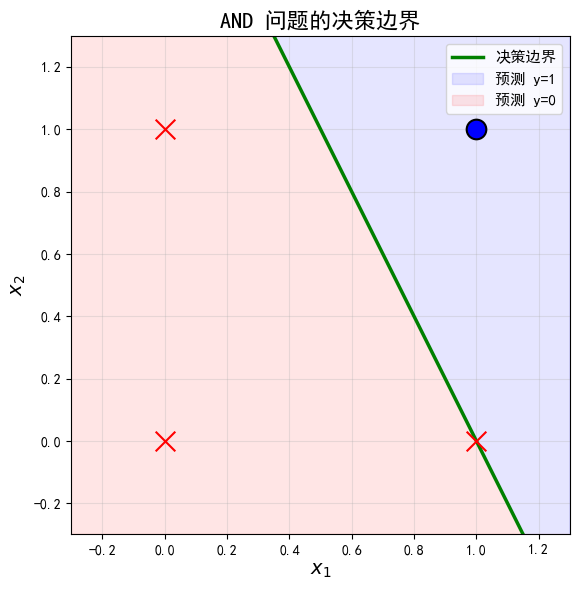

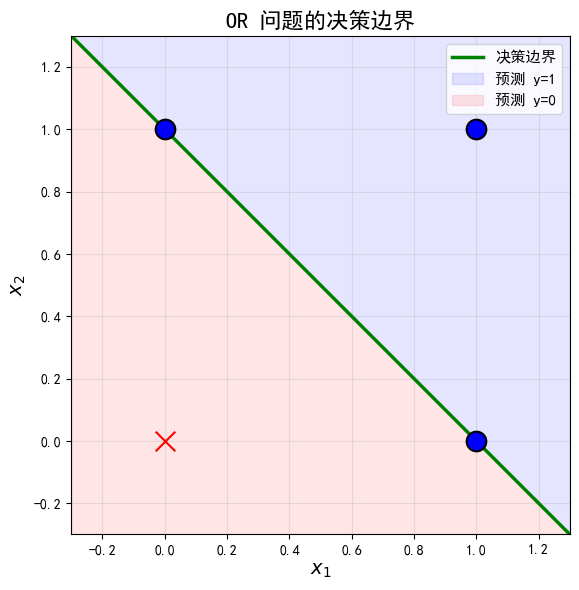

In [11]:
# ============================================
# 可视化决策边界
# ============================================

def plot_decision_boundary(perceptron, X, y, title):
    """绘制感知机的决策边界"""
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    
    # 绘制数据点
    for i in range(len(X)):
        color = 'blue' if y[i] == 1 else 'red'
        marker = 'o' if y[i] == 1 else 'x'
        ax.scatter(X[i, 0], X[i, 1], c=color, marker=marker, s=200, 
                   edgecolors='black', linewidth=1.5, zorder=5)
    
    # 绘制决策边界: w1*x1 + w2*x2 + b = 0
    # => x2 = -(w1*x1 + b) / w2
    if abs(perceptron.W[1]) > 1e-10:
        x1_range = np.linspace(-0.3, 1.3, 100)
        x2_range = -(perceptron.W[0] * x1_range + perceptron.b) / perceptron.W[1]
        ax.plot(x1_range, x2_range, 'g-', linewidth=2.5, label='决策边界')
    
    # 标注区域
    ax.fill_between(x1_range, x2_range, 1.5, alpha=0.1, color='blue', label='预测 y=1')
    ax.fill_between(x1_range, x2_range, -0.3, alpha=0.1, color='red', label='预测 y=0')
    
    ax.set_xlim(-0.3, 1.3)
    ax.set_ylim(-0.3, 1.3)
    ax.set_xlabel('$x_1$', fontsize=14)
    ax.set_ylabel('$x_2$', fontsize=14)
    ax.set_title(title, fontsize=16, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    plt.tight_layout()
    plt.show()

# 绘制 AND 问题的决策边界
plot_decision_boundary(perceptron_and, X_and, y_and, 'AND 问题的决策边界')

# 绘制 OR 问题的决策边界
plot_decision_boundary(perceptron_or, X_or, y_or, 'OR 问题的决策边界')

### 7.5 演示 XOR 不可分性

In [12]:
# ============================================
# XOR 问题——单层感知机的失败
# ============================================

# XOR 真值表
X_xor = np.array([[0, 0],
                   [0, 1],
                   [1, 0],
                   [1, 1]])
y_xor = np.array([0, 1, 1, 0])

print("XOR 真值表:")
print("x₁  x₂  | y (x₁ ⊕ x₂)")
print("---------|-------------")
for xi, yi in zip(X_xor, y_xor):
    print(f" {xi[0]}   {xi[1]}  |     {yi}")

# 尝试用感知机解决 XOR
print("\n尝试用单层感知机解决 XOR 问题...")
perceptron_xor = Perceptron(input_dim=2, lr=0.1, epochs=50)
history_xor = perceptron_xor.train(X_xor, y_xor)

print(f"\n最终权重: W = {perceptron_xor.W}")
print(f"最终偏置: b = {perceptron_xor.b}")

# 验证——看看哪些样本被误分类
print("\n最终预测结果:")
correct = 0
for xi, yi in zip(X_xor, y_xor):
    pred = perceptron_xor.predict(xi.reshape(1, -1))[0]
    status = "✓" if pred == yi else "✗ 错误"
    print(f"  输入 {xi} → 预测 {pred}, 真实 {yi}  {status}")
    if pred == yi:
        correct += 1

print(f"\n准确率: {correct}/{len(y_xor)} = {correct/len(y_xor)*100:.0f}%")

XOR 真值表:
x₁  x₂  | y (x₁ ⊕ x₂)
---------|-------------
 0   0  |     0
 0   1  |     1
 1   0  |     1
 1   1  |     0

尝试用单层感知机解决 XOR 问题...
⚠ 训练 50 轮后未完全收敛，仍有 4 个误分类点

最终权重: W = [-0.1  0. ]
最终偏置: b = 0.0

最终预测结果:
  输入 [0 0] → 预测 1, 真实 0  ✗ 错误
  输入 [0 1] → 预测 1, 真实 1  ✓
  输入 [1 0] → 预测 0, 真实 1  ✗ 错误
  输入 [1 1] → 预测 0, 真实 0  ✓

准确率: 2/4 = 50%


### 7.6 可视化 XOR 问题的不可分性

C:\Users\Terry\AppData\Local\Temp\ipykernel_19848\3571348989.py:12: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax1.scatter(X_xor[i, 0], X_xor[i, 1], c=colors[i], marker=markers[i],
C:\Users\Terry\AppData\Local\Temp\ipykernel_19848\3571348989.py:39: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax2.scatter(X_xor[i, 0], X_xor[i, 1], c=colors[i], marker=markers[i],


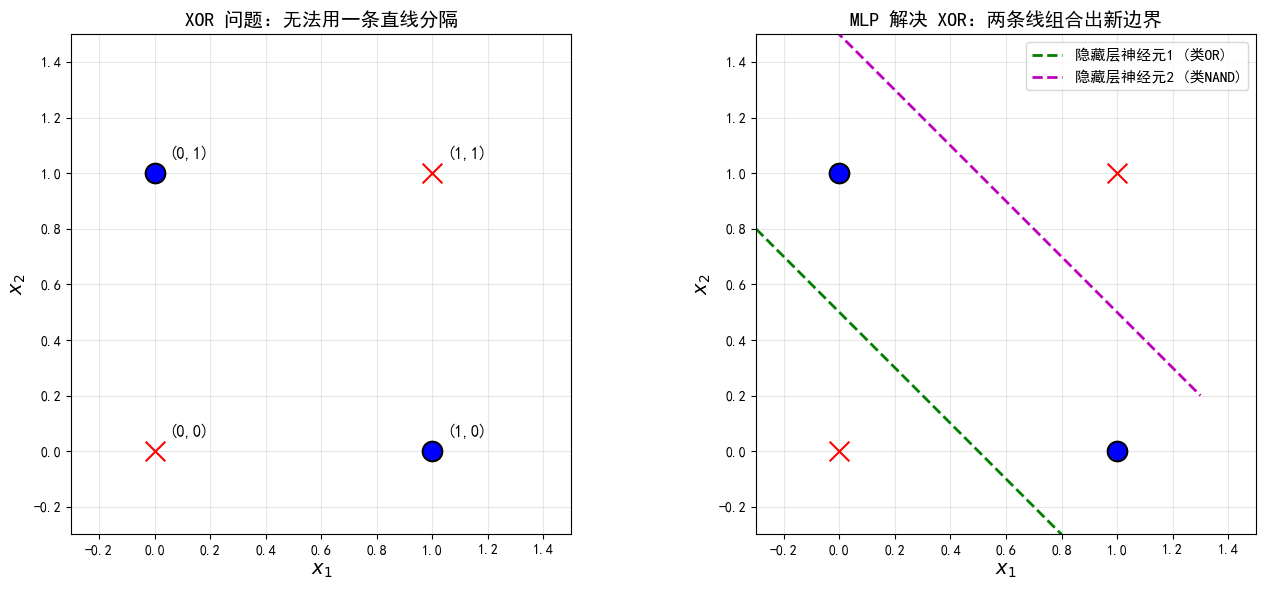

结论：单层感知机只能画出一条直线，而 XOR 需要两条（或曲线）边界。
      添加隐藏层后，MLP 可以组合多个线性边界来处理非线性问题。


In [13]:
# ============================================
# 可视化 XOR 不可分
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 左图：XOR 数据点分布
ax1 = axes[0]
colors = ['red' if y == 0 else 'blue' for y in y_xor]
markers = ['x' if y == 0 else 'o' for y in y_xor]
for i in range(len(X_xor)):
    ax1.scatter(X_xor[i, 0], X_xor[i, 1], c=colors[i], marker=markers[i],
                s=200, edgecolors='black', linewidth=1.5, zorder=5)
    ax1.annotate(f'({X_xor[i,0]},{X_xor[i,1]})', 
                 (X_xor[i,0]+0.05, X_xor[i,1]+0.05), fontsize=12)

ax1.set_xlim(-0.3, 1.5)
ax1.set_ylim(-0.3, 1.5)
ax1.set_xlabel('$x_1$', fontsize=14)
ax1.set_ylabel('$x_2$', fontsize=14)
ax1.set_title('XOR 问题：无法用一条直线分隔', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_aspect('equal')

# 右图：MLP 解决 XOR（用隐藏层的特征变换）
ax2 = axes[1]
# 展示两个半平面的组合
x1 = np.linspace(-0.3, 1.3, 100)
# 隐藏层两个神经元分别学习 OR 和 NAND
# OR: x1 + x2 - 0.5 = 0
x2_or = 0.5 - x1
# NAND: -x1 - x2 + 1.5 = 0
x2_nand = 1.5 - x1

ax2.plot(x1, x2_or, 'g--', linewidth=2, label='隐藏层神经元1 (类OR)')
ax2.plot(x1, x2_nand, 'm--', linewidth=2, label='隐藏层神经元2 (类NAND)')

for i in range(len(X_xor)):
    ax2.scatter(X_xor[i, 0], X_xor[i, 1], c=colors[i], marker=markers[i],
                s=200, edgecolors='black', linewidth=1.5, zorder=5)

ax2.set_xlim(-0.3, 1.5)
ax2.set_ylim(-0.3, 1.5)
ax2.set_xlabel('$x_1$', fontsize=14)
ax2.set_ylabel('$x_2$', fontsize=14)
ax2.set_title('MLP 解决 XOR：两条线组合出新边界', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.set_aspect('equal')

plt.tight_layout()
plt.show()

print("结论：单层感知机只能画出一条直线，而 XOR 需要两条（或曲线）边界。")
print("      添加隐藏层后，MLP 可以组合多个线性边界来处理非线性问题。")

### 7.7 用 Numpy 实现 MLP 解决 XOR（预览下一节内容）

In [14]:
# ============================================
# 简单 MLP 解决 XOR（手动设定权重）
# ============================================

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def mlp_xor(X):
    """
    手动设计的 MLP 解决 XOR
    隐藏层: 2 个神经元
    输出层: 1 个神经元
    
    原理: h1 学习 OR, h2 学习 NAND, 输出层学习 AND(h1, h2)
    """
    # 隐藏层权重 (模拟 OR 和 NAND)
    W1 = np.array([[20, 20],    # h1: 类似 OR
                    [-20, -20]])  # h2: 类似 NAND
    b1 = np.array([-10, 30])
    
    # 输出层权重 (AND)
    W2 = np.array([[20, 20]])
    b2 = np.array([-30])
    
    # 前向传播
    z1 = np.dot(X, W1.T) + b1
    h1 = sigmoid(z1)
    z2 = np.dot(h1, W2.T) + b2
    output = sigmoid(z2)
    
    return h1, output

# 测试
print("MLP 解决 XOR 问题（手动设定权重）:")
print("-" * 50)
hidden, output = mlp_xor(X_xor)
print(f"{'输入':>10} {'隐藏层输出':>20} {'最终输出':>12} {'四舍五入':>10} {'真实':>6}")
print("-" * 50)
for i in range(len(X_xor)):
    print(f"{str(X_xor[i]):>10} {str(np.round(hidden[i], 4)):>20} "
          f"{output[i,0]:>12.4f} {round(output[i,0]):>10} {y_xor[i]:>6}")

print("\n✓ MLP 成功解决了 XOR 问题！")

MLP 解决 XOR 问题（手动设定权重）:
--------------------------------------------------
        输入                隐藏层输出         最终输出       四舍五入     真实
--------------------------------------------------
     [0 0]              [0. 1.]       0.0000          0      0
     [0 1]              [1. 1.]       1.0000          1      1
     [1 0]              [1. 1.]       1.0000          1      1
     [1 1]              [1. 0.]       0.0000          0      0

✓ MLP 成功解决了 XOR 问题！


---

## 📝 练习题

### 题目 1：概念理解

**Q1.** 请写出感知机的数学表达式，并解释每个符号的含义。

<details>
<summary>点击查看答案</summary>

$$y = f(\mathbf{w}^T \mathbf{x} + b)$$

- $\mathbf{x}$：输入特征向量
- $\mathbf{w}$：权重向量
- $b$：偏置
- $f$：激活函数（阶跃函数）
- $\mathbf{w}^T \mathbf{x}$：加权和

</details>

### 题目 2：计算练习

**Q2.** 某感知机的权重 $w_1 = 0.5, w_2 = 0.3$，偏置 $b = -0.4$。对输入 $(1, 1)$ 和 $(0, 1)$，分别计算输出（使用阶跃函数）。

<details>
<summary>点击查看答案</summary>

对输入 $(1, 1)$：$z = 0.5 \times 1 + 0.3 \times 1 + (-0.4) = 0.4 \geq 0 \Rightarrow y = 1$

对输入 $(0, 1)$：$z = 0.5 \times 0 + 0.3 \times 1 + (-0.4) = -0.1 < 0 \Rightarrow y = 0$

</details>

### 题目 3：分析题

**Q3.** 为什么单层感知机无法解决 XOR 问题？请从几何角度解释。

<details>
<summary>点击查看答案</summary>

XOR 问题的正类样本 $(0,1)$ 和 $(1,0)$ 在二维空间中位于对角位置，负类样本 $(0,0)$ 和 $(1,1)$ 同样位于对角位置。没有任何一条直线能够将这两类样本分开。单层感知机的决策边界是一条直线，因此无法解决 XOR 问题。

</details>

### 题目 4：编程题

**Q4.** 修改感知机代码，使用 NOT 真值表训练，观察是否收敛。NOT 真值表：输入 $(0,0) \rightarrow 1$，$(1,0) \rightarrow 0$。

<details>
<summary>点击查看参考答案</summary>

```python
X_not = np.array([[0], [1]])
y_not = np.array([1, 0])

p = Perceptron(input_dim=1, lr=0.1, epochs=20)
p.train(X_not, y_not)
print(f"权重: {p.W}, 偏置: {p.b}")
```

NOT 是线性可分的，所以感知机一定能收敛。

</details>

### 题目 5：竞赛真题风格

**Q5.** 以下关于感知机的说法，正确的是（ ）

A. 感知机可以解决任何二分类问题
B. 感知机只能解决线性可分问题
C. 感知机的激活函数必须是 sigmoid
D. 感知机的学习规则使用了反向传播算法

<details>
<summary>点击查看答案</summary>

**答案：B**

- A 错误：感知机只能解决线性可分问题（如 AND、OR），不能解决 XOR
- B 正确：感知机本质上是一个线性分类器
- C 错误：原始感知机使用阶跃函数作为激活函数
- D 错误：感知机使用的是感知机学习规则（直接更新），不是反向传播

</details>
